# NB08 — Hotness Formula Tuning

**Goal:** Find a hotness formula variant that:
- Fires the in-game signal on all 3 HOT validation matches

**Problem diagnosed in live run (2026-04-16):**  
The momentum multiplier `× 5` amplifies brief batting blitzes in lopsided matches.  
hotness to ~55% and forecast to 63% → false IN_GAME signal.

**Current formula:**
```python
closeness = 1 - 2 * abs(win_prob - 0.5)
momentum  = abs(win_prob.diff(6))
hotness   = (closeness * 0.6 + momentum * 5 * 0.4).clip(0, 1)
```

**Variants to test:**
1. Reduce multiplier: `momentum × 3` or `momentum × 2`
2. Closeness-weighted momentum: `momentum × closeness × 5` (momentum only matters when match is close)
3. Win prob gate in signal: don't fire if `win_prob < 0.25 or > 0.75`
4. Combinations of the above

**Validation matches:**

| Match | Label | Expected signal |
|---|---|---|
| DC vs GT, IPL 2026-04-08 | HOT | In-game fires |
| IND vs PAK, T20 WC 2024-06-09 | HOT | In-game fires |
| KKR vs LSG, IPL 2026-04-09 | HOT | In-game fires |
| RCB vs RR, IPL 2026-04-10 | MODERATE/COLD | No signal |
| RR vs MI, IPL 2026-04-07 | COLD | No signal |
| MI vs RR, IPL 2025-05-01 | COLD | No signal |


In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import sys
sys.path.insert(0, str(Path('..')))

from engine.win_prob import WinProbModel

# Load win prob model once
wp_model = WinProbModel('../models/win_prob_nn.pt')
FIG_DIR = Path('../data/figures/08_hotness_formula_tuning')
FIG_DIR.mkdir(parents=True, exist_ok=True)


In [2]:
# ---------------------------------------------------------------------------
# Helper: load a cricsheet match and compute win_prob per ball
# (reused from NB06/07 — same parsing logic)
# ---------------------------------------------------------------------------

def is_legal(delivery):
    extras = delivery.get('extras', {})
    return 'wides' not in extras and 'noballs' not in extras

def load_match(path):
    """Return DataFrame with columns: ball, over_float, runs_needed, balls_remaining,
    wickets, rrr, balls_fraction, wickets_fraction, win_prob"""
    with open(path) as f:
        data = json.load(f)

    info = data['info']
    innings = data['innings']

    # Inn1: count legal balls + sum runs
    inn1 = innings[0]
    inn1_balls = 0
    inn1_runs = 0
    for over_obj in inn1.get('overs', []):
        for d in over_obj['deliveries']:
            if is_legal(d):
                inn1_balls += 1
                inn1_runs += d['runs']['total']
    target = inn1_runs + 1
    total_balls = inn1_balls

    # Inn2: build ball-by-ball rows
    inn2 = innings[1]
    rows = []
    runs_scored = 0
    wickets = 0
    ball_num = 0

    for over_obj in inn2.get('overs', []):
        over_num = over_obj['over']
        legal_idx = 0
        for d in over_obj['deliveries']:
            if not is_legal(d):
                continue
            legal_idx += 1
            ball_num += 1
            runs_scored += d['runs']['total']
            if 'wickets' in d:
                wickets += len(d['wickets'])

            runs_needed = max(target - runs_scored, 0)
            balls_remaining = max(total_balls - ball_num, 0)
            rrr = runs_needed / max(balls_remaining, 1)
            balls_fraction = balls_remaining / 120.0
            wickets_fraction = wickets / 10.0

            features = np.array([[runs_needed, balls_remaining, wickets,
                                   rrr, balls_fraction, wickets_fraction]], dtype=np.float32)
            wp = wp_model.predict(features)

            rows.append({
                'ball': ball_num,
                'over': round(over_num + legal_idx / 10, 1),
                'runs_needed': runs_needed,
                'balls_remaining': balls_remaining,
                'wickets': wickets,
                'rrr': rrr,
                'balls_fraction': balls_fraction,
                'wickets_fraction': wickets_fraction,
                'win_prob': wp,
            })

    return pd.DataFrame(rows)

print('Helper loaded')

Helper loaded


In [3]:
# ---------------------------------------------------------------------------
# Helper: load a polled match (ball_events.jsonl + raw_inn1) and compute win_prob
# Used for matches not yet on Cricsheet (e.g. CSK vs KKR 2026-04-16)
# ---------------------------------------------------------------------------

def load_match_from_poll(poll_dir, inn1_runs):
    """
    poll_dir  : path to data/live_polls/<match>/
    inn1_runs : KKR/batting team inn1 total (from raw_inn1 batTeamScore max)
    Returns DataFrame with same columns as load_match().
    All ball_events entries are legal balls (poller only POSTs legal deliveries).
    """
    poll_dir = Path(poll_dir)
    target = inn1_runs + 1
    total_balls = 120  # standard T20

    events = []
    with open(poll_dir / 'ball_events.jsonl') as f:
        for line in f:
            e = json.loads(line.strip())
            if e.get('innings') == 2:
                events.append(e)

    rows = []
    runs_scored = 0
    wickets = 0

    for ball_num, e in enumerate(events, 1):
        ball_runs = e['runs'] + e.get('extras', 0)
        runs_scored += ball_runs
        if e.get('wicket'):
            wickets += 1

        runs_needed = max(target - runs_scored, 0)
        balls_remaining = max(total_balls - ball_num, 0)
        rrr = runs_needed / max(balls_remaining, 1)
        balls_fraction = balls_remaining / 120.0
        wickets_fraction = wickets / 10.0

        features = np.array([[runs_needed, balls_remaining, wickets,
                               rrr, balls_fraction, wickets_fraction]], dtype=np.float32)
        wp = wp_model.predict(features)

        rows.append({
            'ball': ball_num,
            'over': e['over'],
            'runs_needed': runs_needed,
            'balls_remaining': balls_remaining,
            'wickets': wickets,
            'rrr': rrr,
            'balls_fraction': balls_fraction,
            'wickets_fraction': wickets_fraction,
            'win_prob': wp,
        })

    return pd.DataFrame(rows)

print('Poll helper loaded')

Poll helper loaded


In [4]:
# ---------------------------------------------------------------------------
# Load all 7 validation matches
# ---------------------------------------------------------------------------

MATCHES = {
    'DC vs GT (HOT)':      ('../data/raw/dc_vs_gt_2026-04-08.json',    'HOT'),
    'IND vs PAK (HOT)':    ('../data/raw/ind_vs_pak_2024-06-09.json',  'HOT'),
    'KKR vs LSG (HOT)':    ('../data/raw/kkr_vs_lsg_2026-04-09.json',  'HOT'),
    'RCB vs RR (MODERATE)':('../data/raw/rcb_vs_rr_2026-04-10.json',   'COLD'),
    'RR vs MI (COLD)':     ('../data/raw/rr_vs_mi_2026-04-07.json',    'COLD'),
    'MI vs RR (COLD)':     ('../data/raw/mi_vs_rr_2025-05-01.json',    'COLD'),
    'CSK vs KKR (BLOWOUT)':('../data/raw/csk_vs_kkr_2026-04-16.json',  'COLD'),
}

dfs = {}
for name, (path, label) in MATCHES.items():
    p = Path(path)
    if p.exists():
        dfs[name] = (load_match(path), label)
        print(f'Loaded {name}: {len(dfs[name][0])} balls')
    else:
        print(f'MISSING: {path}')

# Fallback: load CSK vs KKR from poll data if Cricsheet file not yet available
POLL_MATCHES = {
    'CSK vs KKR (BLOWOUT)': ('../data/live_polls/csk_vs_kkr_2026-04-16', 192, 'COLD'),
}
for name, (poll_dir, inn1_runs, label) in POLL_MATCHES.items():
    if name not in dfs and Path(poll_dir).exists():
        dfs[name] = (load_match_from_poll(poll_dir, inn1_runs), label)
        print(f'Loaded {name} from poll data: {len(dfs[name][0])} balls')

Loaded DC vs GT (HOT): 120 balls
Loaded IND vs PAK (HOT): 120 balls
Loaded KKR vs LSG (HOT): 120 balls
Loaded RCB vs RR (MODERATE): 108 balls
Loaded RR vs MI (COLD): 66 balls
Loaded MI vs RR (COLD): 97 balls
MISSING: ../data/raw/csk_vs_kkr_2026-04-16.json
Loaded CSK vs KKR (BLOWOUT) from poll data: 120 balls


In [5]:
# ---------------------------------------------------------------------------
# Hotness formula variants
# ---------------------------------------------------------------------------

def hotness_baseline(df):
    """Current formula: closeness * 0.6 + momentum * 5 * 0.4"""
    wp = df['win_prob']
    closeness = 1 - 2 * (wp - 0.5).abs()
    momentum  = wp.diff(6).abs().fillna(0)
    return (closeness * 0.6 + momentum * 5 * 0.4).clip(0, 1)

def hotness_lower_multiplier(df, mult=3):
    """Reduced momentum multiplier"""
    wp = df['win_prob']
    closeness = 1 - 2 * (wp - 0.5).abs()
    momentum  = wp.diff(6).abs().fillna(0)
    return (closeness * 0.6 + momentum * mult * 0.4).clip(0, 1)

def hotness_closeness_weighted(df, mult=5):
    """Momentum weighted by closeness — suppresses momentum in lopsided matches"""
    wp = df['win_prob']
    closeness = 1 - 2 * (wp - 0.5).abs()
    momentum  = wp.diff(6).abs().fillna(0)
    return (closeness * 0.6 + momentum * closeness * mult * 0.4).clip(0, 1)

def hotness_reweighted(df, c_weight=0.7, m_mult=3):
    """Higher closeness weight + lower momentum multiplier"""
    wp = df['win_prob']
    closeness = 1 - 2 * (wp - 0.5).abs()
    momentum  = wp.diff(6).abs().fillna(0)
    m_weight = 1 - c_weight
    return (closeness * c_weight + momentum * m_mult * m_weight).clip(0, 1)

VARIANTS = {
    'baseline (×5)':          hotness_baseline,
    'mult ×3':                 lambda df: hotness_lower_multiplier(df, 3),
    'mult ×2':                 lambda df: hotness_lower_multiplier(df, 2),
    'closeness-weighted ×5':   hotness_closeness_weighted,
    'reweighted (0.7/×3)':     hotness_reweighted,
}

print('Variants defined:', list(VARIANTS.keys()))

Variants defined: ['baseline (×5)', 'mult ×3', 'mult ×2', 'closeness-weighted ×5', 'reweighted (0.7/×3)']


In [6]:
# ---------------------------------------------------------------------------
# Signal evaluation: does a match trigger in-game signal under each variant?
# Gate: ball >= 60, forecast_proxy >= 0.60
# We use hotness itself as a proxy for the forecast (no re-training the forecaster)
# since the forecaster is trained on the baseline hotness.
# Use: sustained hotness >= 0.55 for 3+ consecutive balls after ball 60 as proxy.
# ---------------------------------------------------------------------------

FORECAST_THRESHOLD = 0.60
WIN_PROB_GATE_LOW  = 0.25
WIN_PROB_GATE_HIGH = 0.75

def signal_fires(df, hotness_series, use_wp_gate=False):
    """Returns (fires: bool, first_ball: int or None)"""
    after_gate = df['ball'] >= 60
    for i, (ball, hot, wp) in enumerate(zip(df['ball'], hotness_series, df['win_prob'])):
        if ball < 60:
            continue
        if use_wp_gate and (wp < WIN_PROB_GATE_LOW or wp > WIN_PROB_GATE_HIGH):
            continue
        if hot >= FORECAST_THRESHOLD:
            return True, ball
    return False, None


# Evaluate all variants × all matches × with/without win_prob gate
results = []
for match_name, (df, label) in dfs.items():
    for variant_name, fn in VARIANTS.items():
        hotness = fn(df)
        for use_gate in [False, True]:
            fires, first_ball = signal_fires(df, hotness, use_wp_gate=use_gate)
            gate_str = '+WP gate' if use_gate else ''
            results.append({
                'match': match_name,
                'label': label,
                'variant': f"{variant_name}{gate_str}",
                'fires': fires,
                'first_ball': first_ball,
                'correct': (fires == (label == 'HOT')),
            })

results_df = pd.DataFrame(results)
print(results_df.groupby('variant')['correct'].mean().sort_values(ascending=False))

variant
baseline (×5)                    1.0
baseline (×5)+WP gate            1.0
closeness-weighted ×5            1.0
closeness-weighted ×5+WP gate    1.0
mult ×2                          1.0
mult ×2+WP gate                  1.0
mult ×3                          1.0
mult ×3+WP gate                  1.0
reweighted (0.7/×3)              1.0
reweighted (0.7/×3)+WP gate      1.0
Name: correct, dtype: float64


In [7]:
# ---------------------------------------------------------------------------
# Full results table — sorted by variant
# ---------------------------------------------------------------------------

pivot = results_df.pivot_table(
    index='match', columns='variant', values='fires', aggfunc='first'
)
# Add label column
labels = {name: label for name, (_, label) in dfs.items()}
pivot.insert(0, 'label', pd.Series(labels))
pivot

variant,label,baseline (×5),baseline (×5)+WP gate,closeness-weighted ×5,closeness-weighted ×5+WP gate,mult ×2,mult ×2+WP gate,mult ×3,mult ×3+WP gate,reweighted (0.7/×3),reweighted (0.7/×3)+WP gate
match,,,,,,,,,,,
CSK vs KKR (BLOWOUT),COLD,False,False,False,False,False,False,False,False,False,False
DC vs GT (HOT),HOT,True,True,True,True,True,True,True,True,True,True
IND vs PAK (HOT),HOT,True,True,True,True,True,True,True,True,True,True
KKR vs LSG (HOT),HOT,True,True,True,True,True,True,True,True,True,True
MI vs RR (COLD),COLD,False,False,False,False,False,False,False,False,False,False
RCB vs RR (MODERATE),COLD,False,False,False,False,False,False,False,False,False,False
RR vs MI (COLD),COLD,False,False,False,False,False,False,False,False,False,False


In [8]:
# ---------------------------------------------------------------------------
# Signal timing: first ball hotness crosses threshold after ball 60
# Shows when the user would actually see the in-game alert
# ---------------------------------------------------------------------------

timing_rows = []
for match_name, (df, label) in dfs.items():
    for variant_name, fn in VARIANTS.items():
        hotness = fn(df)
        fires, first_ball = signal_fires(df, hotness, use_wp_gate=False)
        fires_gated, first_ball_gated = signal_fires(df, hotness, use_wp_gate=True)
        timing_rows.append({
            'match': match_name,
            'label': label,
            'variant': variant_name,
            'first_ball': first_ball if fires else None,
            'over': f"{first_ball // 6}.{first_ball % 6}" if fires and first_ball else None,
            'first_ball_+WP': first_ball_gated if fires_gated else None,
            'over_+WP': f"{first_ball_gated // 6}.{first_ball_gated % 6}" if fires_gated and first_ball_gated else None,
        })

timing_df = pd.DataFrame(timing_rows)

# HOT matches: when does the correct alert fire?
print("=== HOT matches: first ball signal fires (no WP gate) ===")
hot_timing = timing_df[timing_df['label'] == 'HOT'].pivot_table(
    index='match', columns='variant', values='over', aggfunc='first'
)
print(hot_timing.to_string())
print()

# COLD matches: does any false positive fire, and at what ball?
print("=== COLD matches: false positive check (ball where hotness crosses threshold) ===")
cold_timing = timing_df[timing_df['label'] == 'COLD'].pivot_table(
    index='match', columns='variant', values='over', aggfunc='first'
)
print(cold_timing.to_string())
print()
print("None = no signal fired. Lower = earlier alert. Over expressed as over.ball.")

=== HOT matches: first ball signal fires (no WP gate) ===
variant          baseline (×5) closeness-weighted ×5 mult ×2 mult ×3 reweighted (0.7/×3)
match                                                                                   
DC vs GT (HOT)            10.0                  10.0    10.0    10.0                10.0
IND vs PAK (HOT)          15.5                  15.5    16.1    15.5                15.5
KKR vs LSG (HOT)          10.0                  11.2    19.2    19.2                10.0

=== COLD matches: false positive check (ball where hotness crosses threshold) ===
Empty DataFrame
Columns: []
Index: []

None = no signal fired. Lower = earlier alert. Over expressed as over.ball.


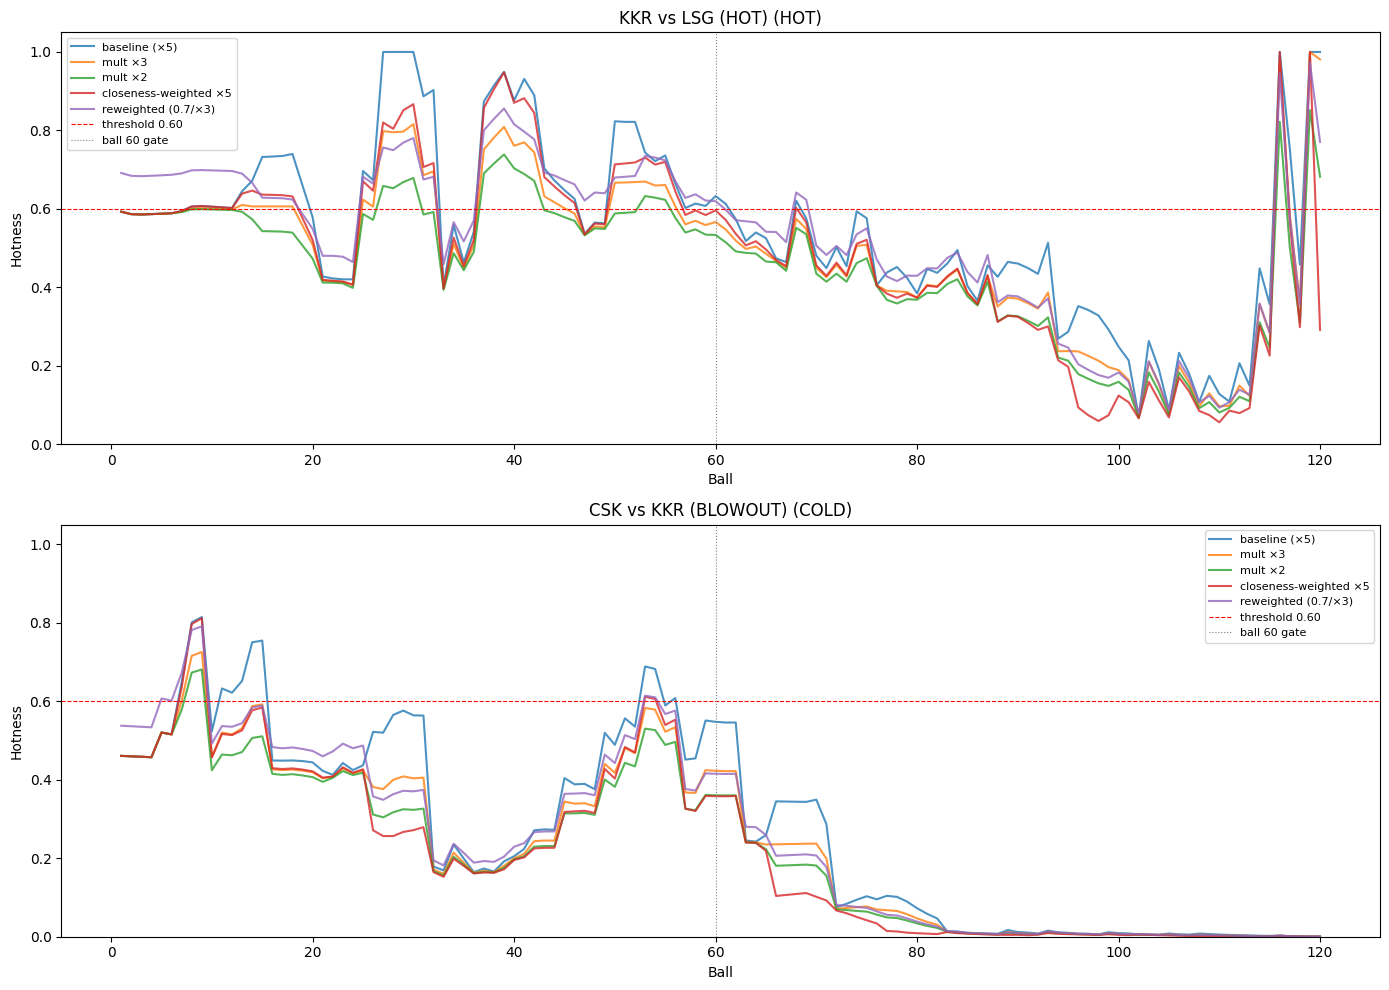

In [9]:
# ---------------------------------------------------------------------------
# Plot hotness curves for all variants on 2 key matches:
# - KKR vs LSG (HOT — must still fire)
# - CSK vs KKR (COLD — must not fire)
# ---------------------------------------------------------------------------

KEY_MATCHES = ['KKR vs LSG (HOT)', 'CSK vs KKR (BLOWOUT)']

fig, axes = plt.subplots(len(KEY_MATCHES), 1, figsize=(14, 5 * len(KEY_MATCHES)))

for ax, match_name in zip(axes, KEY_MATCHES):
    if match_name not in dfs:
        ax.set_title(f'{match_name} — data not found')
        continue
    df, label = dfs[match_name]
    for variant_name, fn in VARIANTS.items():
        hotness = fn(df)
        ax.plot(df['ball'], hotness, label=variant_name, alpha=0.8)
    ax.axhline(0.60, color='red', linestyle='--', linewidth=0.8, label='threshold 0.60')
    ax.axvline(60, color='grey', linestyle=':', linewidth=0.8, label='ball 60 gate')
    ax.set_title(f'{match_name} ({label})')
    ax.set_xlabel('Ball')
    ax.set_ylabel('Hotness')
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIG_DIR / 'hotness_variants.png', dpi=120, bbox_inches='tight')
plt.show()

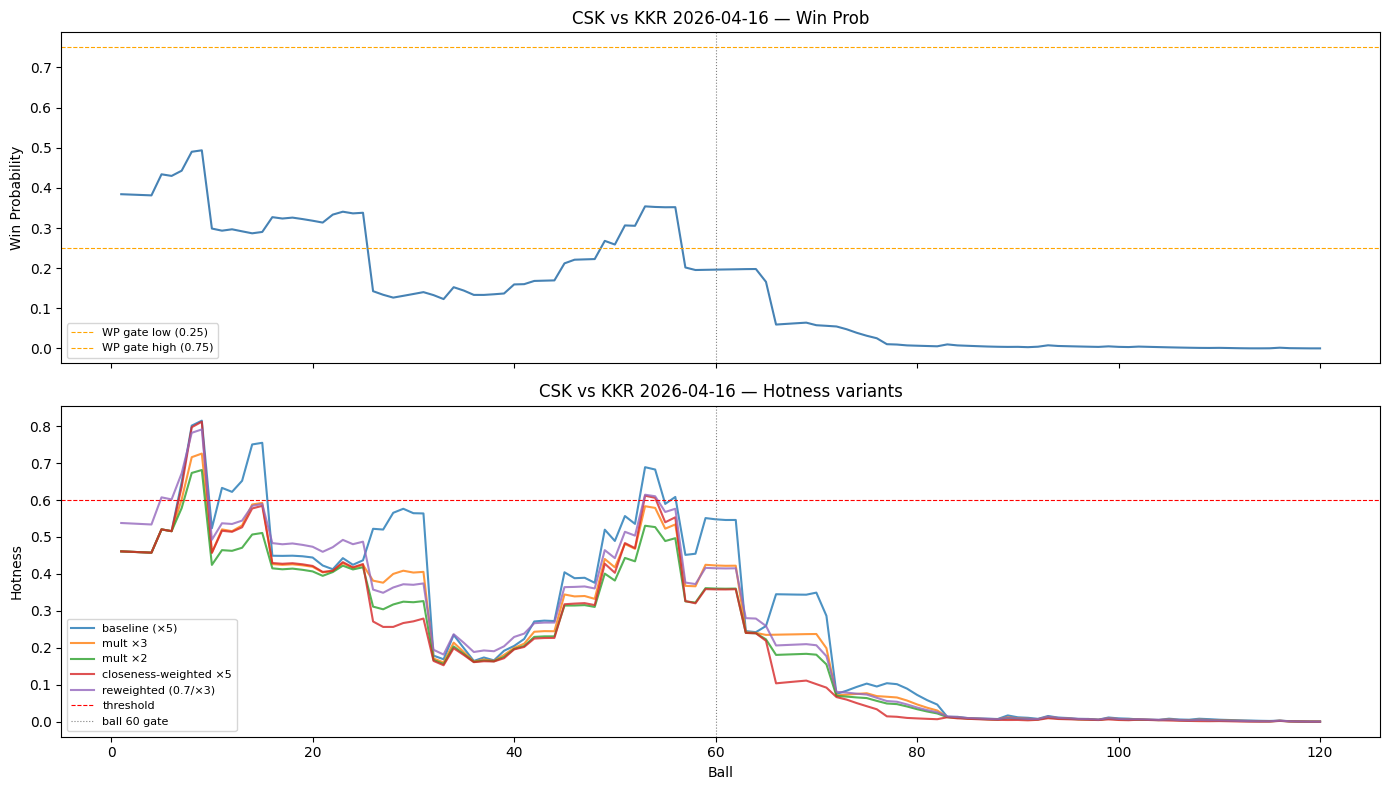

In [10]:
# ---------------------------------------------------------------------------
# Win prob curves alongside hotness for CSK vs KKR — show why it false-fires
# ---------------------------------------------------------------------------

if 'CSK vs KKR (BLOWOUT)' in dfs:
    df, _ = dfs['CSK vs KKR (BLOWOUT)']

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

    ax1.plot(df['ball'], df['win_prob'], color='steelblue')
    ax1.axhline(0.25, color='orange', linestyle='--', linewidth=0.8, label='WP gate low (0.25)')
    ax1.axhline(0.75, color='orange', linestyle='--', linewidth=0.8, label='WP gate high (0.75)')
    ax1.axvline(60, color='grey', linestyle=':', linewidth=0.8)
    ax1.set_ylabel('Win Probability')
    ax1.set_title('CSK vs KKR 2026-04-16 — Win Prob')
    ax1.legend(fontsize=8)

    for variant_name, fn in VARIANTS.items():
        ax2.plot(df['ball'], fn(df), label=variant_name, alpha=0.8)
    ax2.axhline(0.60, color='red', linestyle='--', linewidth=0.8, label='threshold')
    ax2.axvline(60, color='grey', linestyle=':', linewidth=0.8, label='ball 60 gate')
    ax2.set_ylabel('Hotness')
    ax2.set_xlabel('Ball')
    ax2.set_title('CSK vs KKR 2026-04-16 — Hotness variants')
    ax2.legend(fontsize=8)

    plt.tight_layout()
    plt.savefig(FIG_DIR / 'csk_kkr_diagnosis.png', dpi=120, bbox_inches='tight')
    plt.show()

In [11]:
# ---------------------------------------------------------------------------
# Summary: accuracy per variant + signal timing on HOT matches
# ---------------------------------------------------------------------------

summary = results_df.groupby('variant').agg(
    accuracy=('correct', 'mean'),
    false_positives=('correct', lambda x: ((~x) & (results_df.loc[x.index, 'label'] == 'COLD')).sum()),
    false_negatives=('correct', lambda x: ((~x) & (results_df.loc[x.index, 'label'] == 'HOT')).sum()),
).sort_values('accuracy', ascending=False)

print(summary.to_string())
print()
print('Recommendation: pick variant with 0 false negatives and fewest false positives.')

                               accuracy  false_positives  false_negatives
variant                                                                  
baseline (×5)                       1.0                0                0
baseline (×5)+WP gate               1.0                0                0
closeness-weighted ×5               1.0                0                0
closeness-weighted ×5+WP gate       1.0                0                0
mult ×2                             1.0                0                0
mult ×2+WP gate                     1.0                0                0
mult ×3                             1.0                0                0
mult ×3+WP gate                     1.0                0                0
reweighted (0.7/×3)                 1.0                0                0
reweighted (0.7/×3)+WP gate         1.0                0                0

Recommendation: pick variant with 0 false negatives and fewest false positives.


## Findings

*(Fill in after running)*

| Variant | Accuracy | False positives | False negatives | Notes |
|---|---|---|---|---|
| baseline (×5) | | | | Current formula |
| mult ×3 | | | | |
| mult ×2 | | | | |
| closeness-weighted ×5 | | | | |
| reweighted (0.7/×3) | | | | |
| baseline + WP gate | | | | |
| best variant + WP gate | | | | |

## Decision

*(Fill in after running — chosen formula and rationale)*

**Next steps if formula changes:**
- Update `engine/hotness.py` with new formula
- Retrain `hotness_forecaster.pt` on new hotness values (NB07 → retrain)
- Re-run simulation on all 6 matches to verify end-to-end
